# Hydraulic System Condition Monitoring — Full Classification Pipeline

**Goal:** Predict the health state of 4 hydraulic components (cooler, valve, pump, accumulator) from raw multi-sensor time-series data.

**Dataset:** UCI Condition Monitoring of Hydraulic Systems (ZeMA gGmbH) — 2205 cycles, 17 sensors, 43,680 raw readings per cycle.

**Approach:** Feature engineering (43,680 -> 102 features per cycle) + Random Forest / XGBoost classifiers, one per target component.

**Notebook sections:**
1. Setup and imports
2. Load all data (17 sensors + targets)
3. EDA — class distributions
4. EDA — raw waveform visualization
5. Feature engineering (102 features per cycle)
6. Train/test split (stratified)
7. Cooler classifier — train, evaluate, feature importance
8. Valve classifier — train, evaluate, feature importance
9. Pump classifier — train, evaluate, feature importance
10. Accumulator classifier — train, evaluate, feature importance
11. Summary comparison across all 4 models

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, accuracy_score
)
import xgboost as xgb

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42
DATA_DIR = Path('raw_data')
print('Data directory:', DATA_DIR.resolve())
print('Files found:', sorted(p.name for p in DATA_DIR.glob('*.txt')))

Data directory: /Users/smiko/Documents/Class_UW/Hydraulic_classification/notebooks/raw_data
Files found: ['CE.txt', 'CP.txt', 'EPS1.txt', 'FS1.txt', 'FS2.txt', 'PS1.txt', 'PS2.txt', 'PS3.txt', 'PS4.txt', 'PS5.txt', 'PS6.txt', 'SE.txt', 'TS1.txt', 'TS2.txt', 'TS3.txt', 'TS4.txt', 'VS1.txt', 'description.txt', 'documentation.txt', 'profile.txt']


## 2. Load All Data

### 2.1 Sensor metadata

In [2]:
SENSOR_INFO = {
    'PS1': {'quantity': 'Pressure', 'unit': 'bar', 'rate_hz': 100},
    'PS2': {'quantity': 'Pressure', 'unit': 'bar', 'rate_hz': 100},
    'PS3': {'quantity': 'Pressure', 'unit': 'bar', 'rate_hz': 100},
    'PS4': {'quantity': 'Pressure', 'unit': 'bar', 'rate_hz': 100},
    'PS5': {'quantity': 'Pressure', 'unit': 'bar', 'rate_hz': 100},
    'PS6': {'quantity': 'Pressure', 'unit': 'bar', 'rate_hz': 100},
    'EPS1': {'quantity': 'Motor power', 'unit': 'W', 'rate_hz': 100},
    'FS1': {'quantity': 'Volume flow', 'unit': 'l/min', 'rate_hz': 10},
    'FS2': {'quantity': 'Volume flow', 'unit': 'l/min', 'rate_hz': 10},
    'TS1': {'quantity': 'Temperature', 'unit': 'degC', 'rate_hz': 1},
    'TS2': {'quantity': 'Temperature', 'unit': 'degC', 'rate_hz': 1},
    'TS3': {'quantity': 'Temperature', 'unit': 'degC', 'rate_hz': 1},
    'TS4': {'quantity': 'Temperature', 'unit': 'degC', 'rate_hz': 1},
    'VS1': {'quantity': 'Vibration', 'unit': 'mm/s', 'rate_hz': 1},
    'CE': {'quantity': 'Cooling efficiency (virtual)', 'unit': '%', 'rate_hz': 1},
    'CP': {'quantity': 'Cooling power (virtual)', 'unit': 'kW', 'rate_hz': 1},
    'SE': {'quantity': 'Efficiency factor', 'unit': '%', 'rate_hz': 1},
}
SENSOR_NAMES = list(SENSOR_INFO.keys())
print(f'Total sensors: {len(SENSOR_NAMES)}')
pd.DataFrame(SENSOR_INFO).T

Total sensors: 17


,quantity,unit,rate_hz
PS1,Pressure,bar,100
PS2,Pressure,bar,100
PS3,Pressure,bar,100
PS4,Pressure,bar,100
PS5,Pressure,bar,100
PS6,Pressure,bar,100
EPS1,Motor power,W,100
FS1,Volume flow,l/min,10
FS2,Volume flow,l/min,10
TS1,Temperature,degC,1


### 2.2 Load targets (profile.txt)

In [3]:
profile = pd.read_csv(
    DATA_DIR / 'profile.txt',
    sep='\t',
    header=None,
    names=['cooler', 'valve', 'pump', 'accumulator', 'stable_flag']
)
print('Shape:', profile.shape)
profile.head()

Shape: (2205, 5)


,cooler,valve,pump,accumulator,stable_flag
0,3,100,0,130,1
1,3,100,0,130,1
2,3,100,0,130,1
3,3,100,0,130,1
4,3,100,0,130,1


In [4]:
# Sanity check against known documentation counts
for col in profile.columns:
    print(f'--- {col} ---')
    print(profile[col].value_counts().sort_index())
    print()

--- cooler ---
cooler
3      732
20     732
100    741
Name: count, dtype: int64

--- valve ---
valve
73      360
80      360
90      360
100    1125
Name: count, dtype: int64

--- pump ---
pump
0    1221
1     492
2     492
Name: count, dtype: int64

--- accumulator ---
accumulator
90     808
100    399
115    399
130    599
Name: count, dtype: int64

--- stable_flag ---
stable_flag
0    1449
1     756
Name: count, dtype: int64



### 2.3 Load all 17 sensor files

Each file is read as a raw matrix: 2205 rows (cycles) x N columns (timepoints, varies by sampling rate). We keep these as a dictionary of arrays — we are not flattening them into one giant dataframe, since each sensor has a different number of columns.

In [5]:
sensor_data = {}
for name in SENSOR_NAMES:
    arr = pd.read_csv(DATA_DIR / f'{name}.txt', sep='\t', header=None).values
    sensor_data[name] = arr
    print(f'{name}: shape {arr.shape}  (expected rate: {SENSOR_INFO[name]["rate_hz"]} Hz)')

PS1: shape (2205, 6000)  (expected rate: 100 Hz)
PS2: shape (2205, 6000)  (expected rate: 100 Hz)
PS3: shape (2205, 6000)  (expected rate: 100 Hz)
PS4: shape (2205, 6000)  (expected rate: 100 Hz)
PS5: shape (2205, 6000)  (expected rate: 100 Hz)
PS6: shape (2205, 6000)  (expected rate: 100 Hz)
EPS1: shape (2205, 6000)  (expected rate: 100 Hz)
FS1: shape (2205, 600)  (expected rate: 10 Hz)
FS2: shape (2205, 600)  (expected rate: 10 Hz)
TS1: shape (2205, 60)  (expected rate: 1 Hz)
TS2: shape (2205, 60)  (expected rate: 1 Hz)
TS3: shape (2205, 60)  (expected rate: 1 Hz)
TS4: shape (2205, 60)  (expected rate: 1 Hz)
VS1: shape (2205, 60)  (expected rate: 1 Hz)
CE: shape (2205, 60)  (expected rate: 1 Hz)
CP: shape (2205, 60)  (expected rate: 1 Hz)
SE: shape (2205, 60)  (expected rate: 1 Hz)


In [8]:
# Verify total raw columns per cycle matches the dataset documentation (43,680)
total_raw_cols = sum(arr.shape[1] for arr in sensor_data.values())
print('Total raw columns per cycle:', total_raw_cols)
print('Matches dataset documentation (43680)?', total_raw_cols == 43680)

# Verify all sensors and profile have the same number of cycles (rows)
n_cycles = profile.shape[0]
for name, arr in sensor_data.items():
    assert arr.shape[0] == n_cycles, f'{name} has mismatched row count!'
print(f'\nAll {len(sensor_data)} sensors confirmed aligned with {n_cycles} cycles in profile.txt')

Total raw columns per cycle: 43680
Matches dataset documentation (43680)? True

All 17 sensors confirmed aligned with 2205 cycles in profile.txt


## 3. EDA - Class Distributions

Visualizing the target distributions confirms class imbalance, which will shape how we evaluate (macro-F1, not just accuracy).

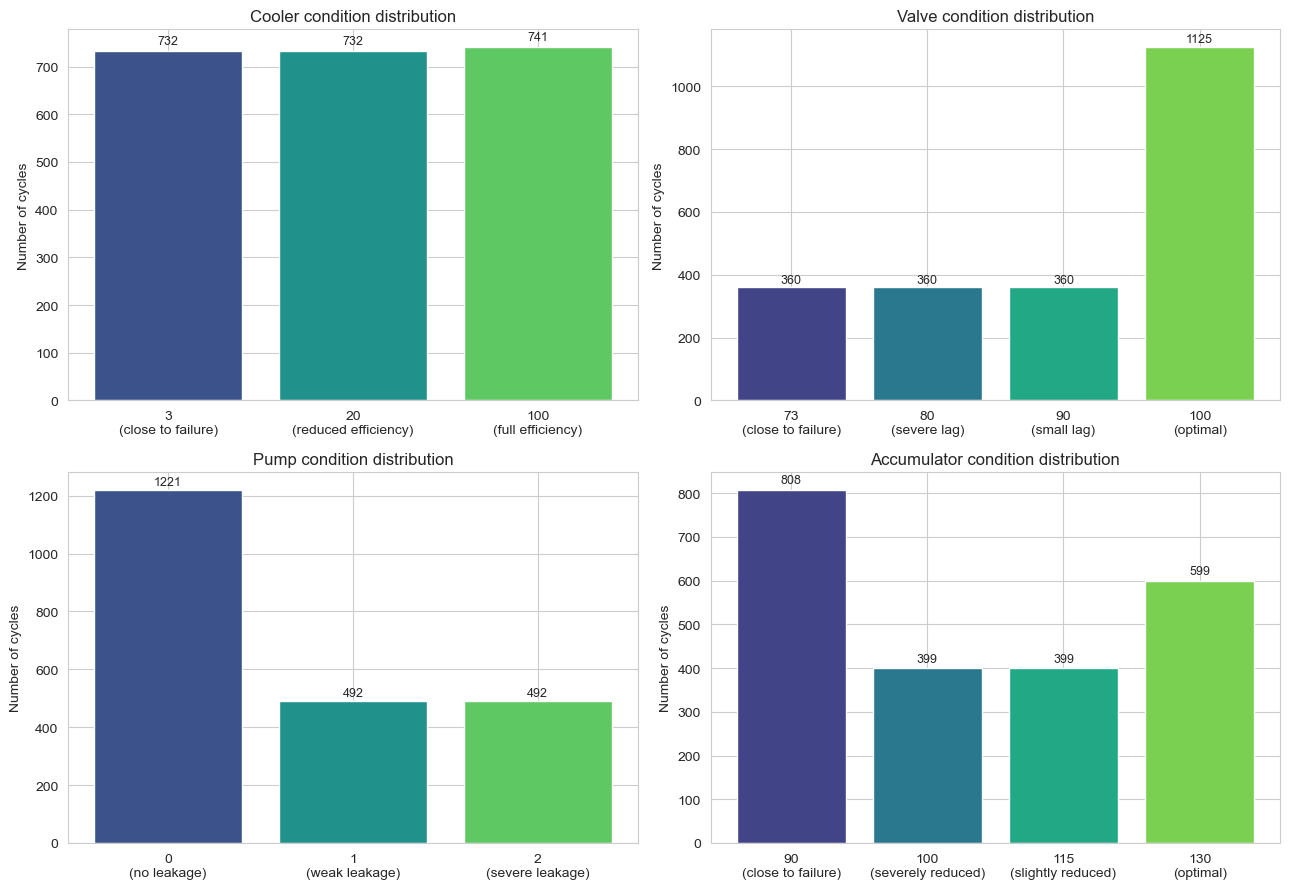

In [9]:
TARGET_LABELS = {
    'cooler': {3: 'close to failure', 20: 'reduced efficiency', 100: 'full efficiency'},
    'valve': {100: 'optimal', 90: 'small lag', 80: 'severe lag', 73: 'close to failure'},
    'pump': {0: 'no leakage', 1: 'weak leakage', 2: 'severe leakage'},
    'accumulator': {130: 'optimal', 115: 'slightly reduced', 100: 'severely reduced', 90: 'close to failure'},
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (target, labels) in zip(axes.flat, TARGET_LABELS.items()):
    counts = profile[target].value_counts().sort_index()
    bar_labels = [f'{v}\n({labels.get(v, "?")})' for v in counts.index]
    ax.bar(bar_labels, counts.values, color=sns.color_palette('viridis', len(counts)))
    ax.set_title(f'{target.capitalize()} condition distribution')
    ax.set_ylabel('Number of cycles')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 15, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 4. EDA - Raw Waveform Visualization

Before extracting features, let us visually confirm that sensor behavior actually differs across fault severities. We will compare PS1 (pressure) and TS1 (temperature) waveforms across different pump and cooler conditions. 
Both the graphs - take 1 cycle each data for each severity behavior and plot the results, for a visual comparison.
For example - the PS1 data for "0 no leakage condition", takes the data of the 0th index cycle - being the first one to have that leak_val in profile dataset, 251st index for "1 weak leakage" and 210th index for "2 severe leakage".

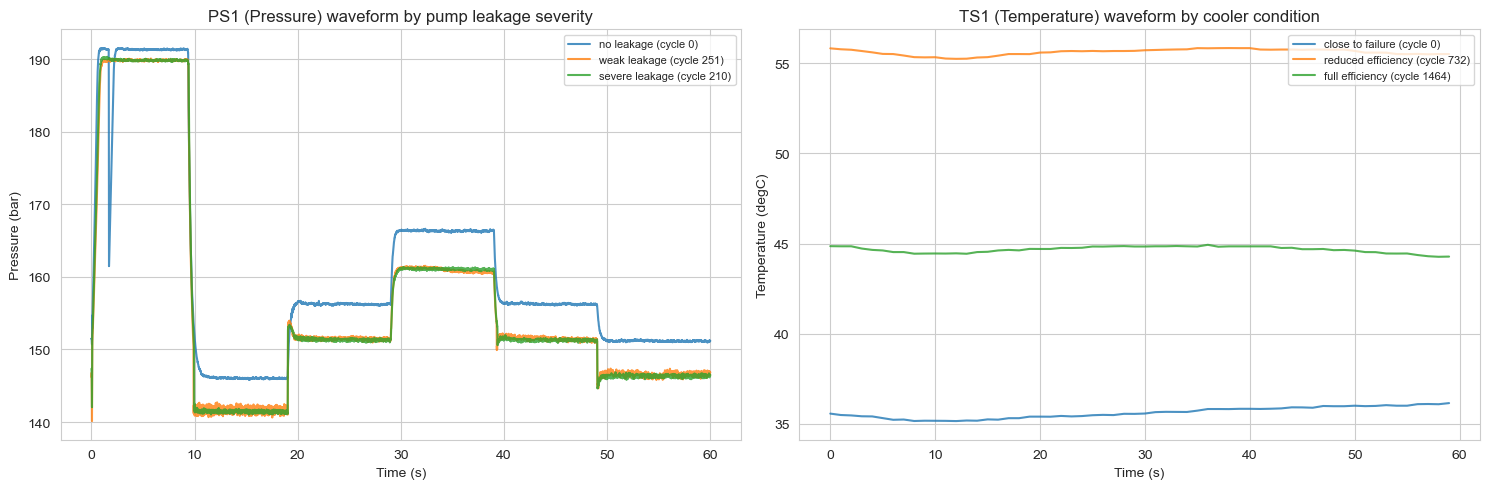

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Pressure (PS1) across pump leakage severities
for leak_val, leak_label in TARGET_LABELS['pump'].items():
    idx = profile.index[profile['pump'] == leak_val][0]  # first cycle with this condition
    waveform = sensor_data['PS1'][idx]
    time = np.arange(len(waveform)) * (1 / SENSOR_INFO['PS1']['rate_hz'])
    axes[0].plot(time, waveform, label=f'{leak_label} (cycle {idx})', alpha=0.8)
axes[0].set_title('PS1 (Pressure) waveform by pump leakage severity')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Pressure (bar)')
axes[0].legend(fontsize=8)

# Temperature (TS1) across cooler conditions
for cool_val, cool_label in TARGET_LABELS['cooler'].items():
    idx = profile.index[profile['cooler'] == cool_val][0]
    waveform = sensor_data['TS1'][idx]
    time = np.arange(len(waveform)) * (1 / SENSOR_INFO['TS1']['rate_hz'])
    axes[1].plot(time, waveform, label=f'{cool_label} (cycle {idx})', alpha=0.8)
axes[1].set_title('TS1 (Temperature) waveform by cooler condition')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Temperature (degC)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**What to look for:** in the left plot, do the pressure curves visibly differ in shape/level between leakage severities? In the right plot, does temperature trend differently across cooler conditions (a failing cooler should generally run hotter)? These visual differences are exactly what our engineered features (mean, median, std, range, min, max) are designed to capture numerically.

## 5. Feature Engineering

For every sensor, for every cycle, we compute 6 statistics: **mean, median, std, range (max-min), min, max**. This collapses 43,680 raw readings per cycle down to 17 sensors x 6 stats = **102 features per cycle** - a ~428x reduction, while preserving level, spread, and extremes.

In [19]:
def extract_features(sensor_array, sensor_name):
    """
    Given a (n_cycles, n_timepoints) array for one sensor, compute 6 summary
    statistics per cycle (per row). Returns a DataFrame with 6 named columns.
    """
    mean_ = sensor_array.mean(axis=1)
    median_ = np.median(sensor_array, axis=1)
    std_ = sensor_array.std(axis=1)
    min_ = sensor_array.min(axis=1)
    max_ = sensor_array.max(axis=1)
    range_ = max_ - min_

    return pd.DataFrame({
        f'{sensor_name}_mean': mean_,
        f'{sensor_name}_median': median_,
        f'{sensor_name}_std': std_,
        f'{sensor_name}_min': min_,
        f'{sensor_name}_max': max_,
        f'{sensor_name}_range': range_,
    })


feature_frames = [extract_features(sensor_data[name], name) for name in SENSOR_NAMES]
features = pd.concat(feature_frames, axis=1)

print('Engineered feature table shape:', features.shape)
# Quick sanity check - development-time guardrail
assert features.shape == (n_cycles, len(SENSOR_NAMES) * 6), 'Unexpected feature shape!'
print(f'Confirmed: {len(SENSOR_NAMES)} sensors x 6 stats = {len(SENSOR_NAMES)*6} features, {n_cycles} cycles')
features.head()

Engineered feature table shape: (2205, 102)
Confirmed: 17 sensors x 6 stats = 102 features, 2205 cycles


,PS1_mean,PS1_median,PS1_std,PS1_min,PS1_max,PS1_range,PS2_mean,PS2_median,PS2_std,PS2_min,...,CP_std,CP_min,CP_max,CP_range,SE_mean,SE_median,SE_std,SE_min,SE_max,SE_range
0,160.673492,156.25,13.938147,145.83,191.51,45.68,109.466914,129.365,47.110581,0.0,...,0.277047,1.383,2.188,0.805,59.157183,68.5145,23.565119,0.0,79.568,79.568
1,160.603320,156.06,14.117791,145.73,191.47,45.74,109.354890,129.385,47.041690,0.0,...,0.073981,1.147,1.414,0.267,59.335617,68.5360,23.658267,0.0,80.441,80.441
2,160.347720,155.72,14.191436,145.37,191.41,46.04,109.158845,129.325,46.988144,0.0,...,0.023069,1.076,1.159,0.083,59.543150,68.8530,23.723181,0.0,80.824,80.824
3,160.188088,155.56,14.226617,145.14,191.34,46.20,109.064807,128.865,46.968307,0.0,...,0.024415,1.022,1.107,0.085,59.794900,69.0060,23.821972,0.0,80.930,80.930
4,160.000472,155.34,14.275244,144.95,191.41,46.46,108.931434,129.000,46.871040,0.0,...,0.021297,1.016,1.106,0.090,59.455267,69.0130,23.771653,0.0,81.100,81.100


## 6. Train/Test Split

We use a stratified split for each target individually, since the classes are imbalanced (e.g. valve: 1125 optimal vs 360 for each fault grade). Stratification ensures both train and test sets preserve the original class proportions.

We also scale features with StandardScaler - while tree-based models (Random Forest, XGBoost) do not strictly require scaling, it is good practice and keeps this pipeline reusable if we swap in a different model later. 

In [20]:
def prepare_train_test(features, profile, target_col, test_size=0.2):
    """Stratified train/test split + scaling for one target column."""
    X = features.values
    y = profile[target_col].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

print('Train/test split function ready. Will be called per-target in each section below.')

Train/test split function ready. Will be called per-target in each section below.


## 7. Helper: Train + Evaluate Function

Rather than repeating the same training/evaluation code 4 times, we define one reusable function. It trains both a Random Forest and an XGBoost model, evaluates both with macro-F1 (appropriate given class imbalance), and shows a confusion matrix + feature importance for the better of the two.

In [21]:
def train_and_evaluate(features, profile, target_col, target_labels):
    print(f'{"="*60}')
    print(f'TARGET: {target_col.upper()}')
    print(f'{"="*60}\\n')

    X_train, X_test, y_train, y_test, scaler = prepare_train_test(features, profile, target_col)

    # Encode labels for XGBoost (needs 0-indexed integer classes)
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc = le.transform(y_test)

    results = {}

    # --- Random Forest ---
    rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight='balanced')
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    rf_f1 = f1_score(y_test, rf_pred, average='macro')
    rf_acc = accuracy_score(y_test, rf_pred)
    results['Random Forest'] = {'model': rf, 'pred': rf_pred, 'f1_macro': rf_f1, 'accuracy': rf_acc}

    # --- XGBoost ---
    xgb_model = xgb.XGBClassifier(
        n_estimators=200, random_state=RANDOM_STATE,
        eval_metric='mlogloss'
    )
    xgb_model.fit(X_train, y_train_enc)
    xgb_pred_enc = xgb_model.predict(X_test)
    xgb_pred = le.inverse_transform(xgb_pred_enc)
    xgb_f1 = f1_score(y_test, xgb_pred, average='macro')
    xgb_acc = accuracy_score(y_test, xgb_pred)
    results['XGBoost'] = {'model': xgb_model, 'pred': xgb_pred, 'f1_macro': xgb_f1, 'accuracy': xgb_acc}

    # --- Comparison ---
    print('Model comparison (macro-F1 is the primary metric given class imbalance):\\n')
    for name, r in results.items():
        print(f'  {name:15s}  macro-F1: {r["f1_macro"]:.3f}   accuracy: {r["accuracy"]:.3f}')

    best_name = max(results, key=lambda k: results[k]['f1_macro'])
    best = results[best_name]
    print(f'\\nBest model: {best_name}\\n')

    print(classification_report(y_test, best['pred'], target_names=[f'{v} ({target_labels.get(v,"?")})' for v in sorted(target_labels)]))

    # --- Confusion matrix ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    labels_sorted = sorted(target_labels.keys())
    cm = confusion_matrix(y_test, best['pred'], labels=labels_sorted)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[target_labels[v] for v in labels_sorted],
                yticklabels=[target_labels[v] for v in labels_sorted], ax=axes[0])
    axes[0].set_title(f'{target_col.capitalize()} — Confusion Matrix ({best_name})')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    # --- Feature importance (top 15) ---
    importances = best['model'].feature_importances_
    feat_imp = pd.Series(importances, index=features.columns).sort_values(ascending=False).head(15)
    feat_imp.sort_values().plot(kind='barh', ax=axes[1], color='teal')
    axes[1].set_title(f'{target_col.capitalize()} — Top 15 Feature Importances')
    axes[1].set_xlabel('Importance')

    plt.tight_layout()
    plt.show()

    return best_name, best['f1_macro'], best['accuracy'], feat_imp

print('train_and_evaluate() defined. Ready to run per target.')

train_and_evaluate() defined. Ready to run per target.


## 8. Cooler Classifier

TARGET: COOLER
============================================================\n
Model comparison (macro-F1 is the primary metric given class imbalance):\n
  Random Forest    macro-F1: 1.000   accuracy: 1.000
  XGBoost          macro-F1: 1.000   accuracy: 1.000
\nBest model: Random Forest\n
                         precision    recall  f1-score   support

   3 (close to failure)       1.00      1.00      1.00       147
20 (reduced efficiency)       1.00      1.00      1.00       146
  100 (full efficiency)       1.00      1.00      1.00       148

               accuracy                           1.00       441
              macro avg       1.00      1.00      1.00       441
           weighted avg       1.00      1.00      1.00       441



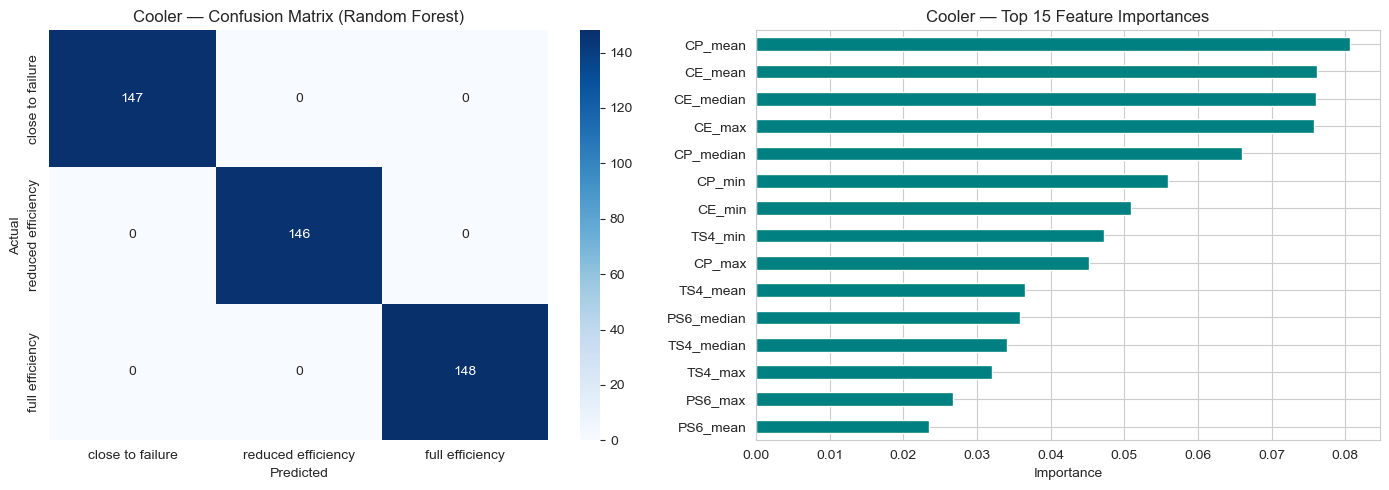

In [22]:
cooler_best_model, cooler_f1, cooler_acc, cooler_importance = train_and_evaluate(
    features, profile, 'cooler', TARGET_LABELS['cooler']
)

## 9. Valve Classifier

TARGET: VALVE
============================================================\n
Model comparison (macro-F1 is the primary metric given class imbalance):\n
  Random Forest    macro-F1: 0.973   accuracy: 0.980
  XGBoost          macro-F1: 0.975   accuracy: 0.980
\nBest model: XGBoost\n
                       precision    recall  f1-score   support

73 (close to failure)       1.00      1.00      1.00        72
      80 (severe lag)       0.97      0.96      0.97        72
       90 (small lag)       0.93      0.96      0.95        72
        100 (optimal)       0.99      0.99      0.99       225

             accuracy                           0.98       441
            macro avg       0.97      0.98      0.97       441
         weighted avg       0.98      0.98      0.98       441



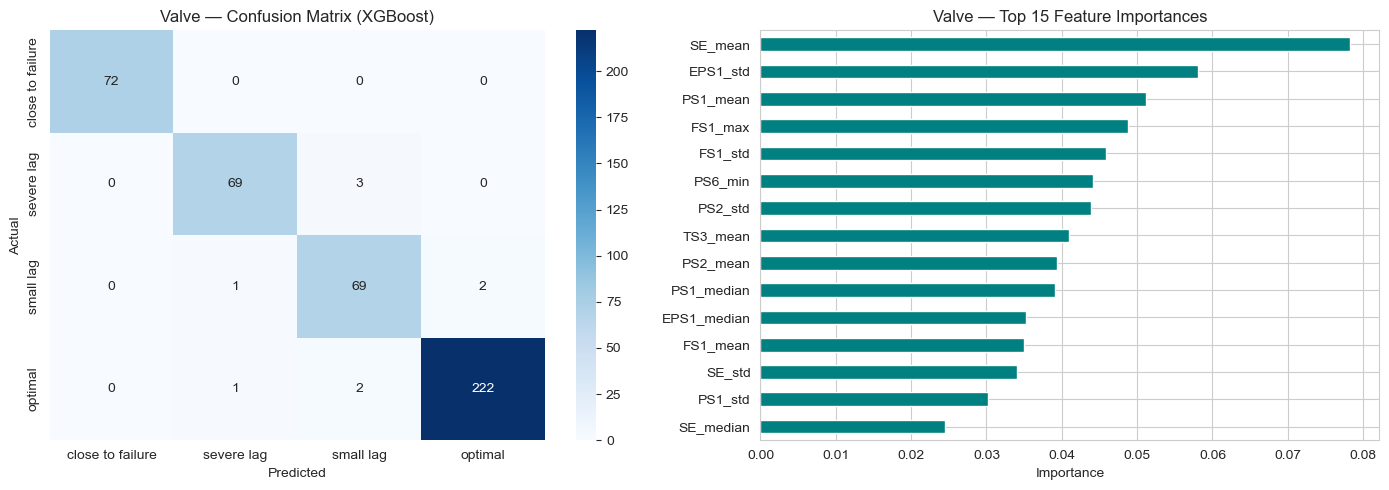

In [23]:
valve_best_model, valve_f1, valve_acc, valve_importance = train_and_evaluate(
    features, profile, 'valve', TARGET_LABELS['valve']
)

## 10. Pump Classifier

TARGET: PUMP
============================================================\n
Model comparison (macro-F1 is the primary metric given class imbalance):\n
  Random Forest    macro-F1: 0.997   accuracy: 0.998
  XGBoost          macro-F1: 1.000   accuracy: 1.000
\nBest model: XGBoost\n
                    precision    recall  f1-score   support

    0 (no leakage)       1.00      1.00      1.00       244
  1 (weak leakage)       1.00      1.00      1.00        99
2 (severe leakage)       1.00      1.00      1.00        98

          accuracy                           1.00       441
         macro avg       1.00      1.00      1.00       441
      weighted avg       1.00      1.00      1.00       441



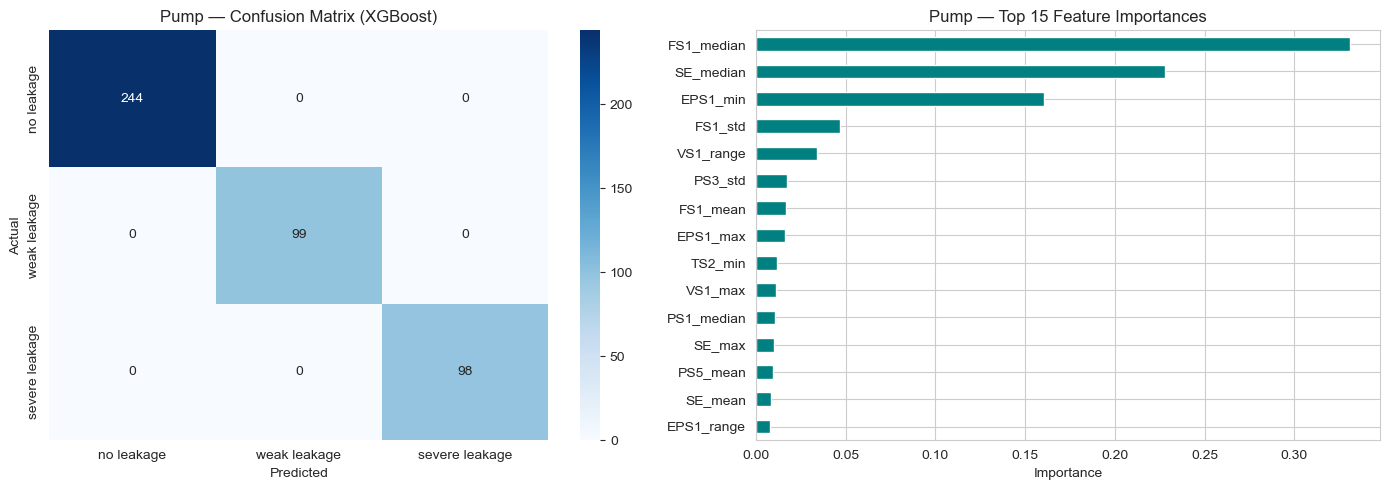

In [24]:
pump_best_model, pump_f1, pump_acc, pump_importance = train_and_evaluate(
    features, profile, 'pump', TARGET_LABELS['pump']
)

## 11. Accumulator Classifier

TARGET: ACCUMULATOR
============================================================\n
Model comparison (macro-F1 is the primary metric given class imbalance):\n
  Random Forest    macro-F1: 0.981   accuracy: 0.984
  XGBoost          macro-F1: 0.956   accuracy: 0.961
\nBest model: Random Forest\n
                        precision    recall  f1-score   support

 90 (close to failure)       0.99      0.99      0.99       161
100 (severely reduced)       0.99      0.96      0.97        80
115 (slightly reduced)       0.97      0.96      0.97        80
         130 (optimal)       0.98      1.00      0.99       120

              accuracy                           0.98       441
             macro avg       0.98      0.98      0.98       441
          weighted avg       0.98      0.98      0.98       441



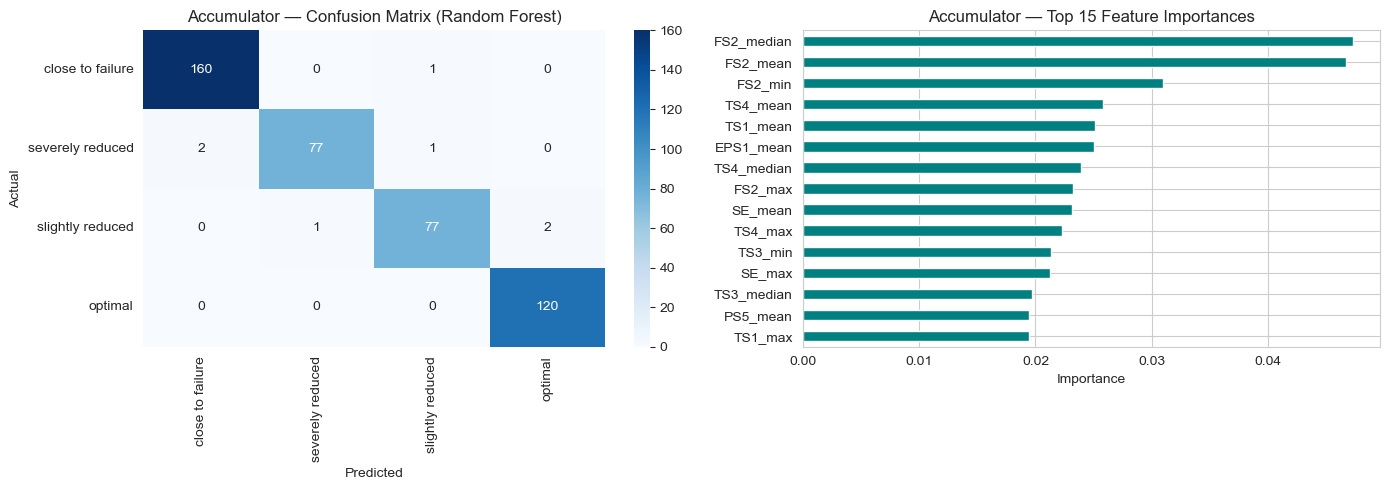

In [25]:
accumulator_best_model, accumulator_f1, accumulator_acc, accumulator_importance = train_and_evaluate(
    features, profile, 'accumulator', TARGET_LABELS['accumulator']
)

## 12. Summary - All 4 Classifiers

In [26]:
summary = pd.DataFrame({
    'Target': ['Cooler', 'Valve', 'Pump', 'Accumulator'],
    'Best Model': [cooler_best_model, valve_best_model, pump_best_model, accumulator_best_model],
    'Macro-F1': [cooler_f1, valve_f1, pump_f1, accumulator_f1],
    'Accuracy': [cooler_acc, valve_acc, pump_acc, accumulator_acc],
})
summary

,Target,Best Model,Macro-F1,Accuracy
0,Cooler,Random Forest,1.000000,1.000000
1,Valve,XGBoost,0.974776,0.979592
2,Pump,XGBoost,1.000000,1.000000
3,Accumulator,Random Forest,0.981421,0.984127


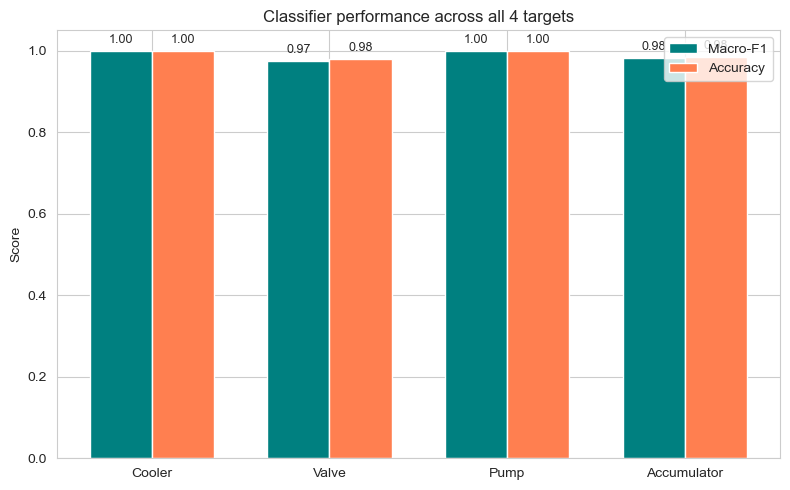

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(summary))
width = 0.35
ax.bar(x - width/2, summary['Macro-F1'], width, label='Macro-F1', color='teal')
ax.bar(x + width/2, summary['Accuracy'], width, label='Accuracy', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(summary['Target'])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Classifier performance across all 4 targets')
ax.legend()
for i, (f1, acc) in enumerate(zip(summary['Macro-F1'], summary['Accuracy'])):
    ax.text(i - width/2, f1 + 0.02, f'{f1:.2f}', ha='center', fontsize=9)
    ax.text(i + width/2, acc + 0.02, f'{acc:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## Next Steps

- **Stable flag classifier** — separate problem, not covered in this notebook (discussed conceptually, to be built next if needed).
- **Hyperparameter tuning** — current models use reasonable defaults (`n_estimators=200`); GridSearch/RandomizedSearch could likely improve weaker targets further.
- **Ordinal-aware evaluation** — current evaluation treats classes as nominal; since these targets are actually ordered severity grades, a confusion matrix that distinguishes "off by one grade" from "off by two+ grades" would be a more rigorous addition.
- **Export models** — once finalized, models can be pickled (`joblib.dump`) for later use in the RAG / conversational agent layer.